# 모바일 신체 활동 상태 (mActivity) 심층 EDA

이 노트북은 `ch2025_mActivity.parquet` 데이터를 분석합니다.
스마트폰의 가속도 및 상태 센서 등으로 탐지된 사용자의 일일 활동 정보를 파악합니다.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntEnum

class ActivityType(IntEnum):
    VEHICLE = 0      # 차량
    BICYCLE = 1      # 자전거
    FOOT = 2         # 보행(foot)
    STILL = 3        # 정지
    UNKNOWN = 4      # 알수없음
    TILTING = 5      # 기울기
    WALKING = 7      # 걷기
    RUNNING = 8      # 달리기

    @classmethod
    def to_name(cls, val):
        names = {
            cls.VEHICLE: "차량(0)",
            cls.BICYCLE: "자전거(1)",
            cls.FOOT: "보행(foot)(2)",
            cls.STILL: "정지(3)",
            cls.UNKNOWN: "알수없음(4)",
            cls.TILTING: "기울기(5)",
            cls.WALKING: "걷기(7)",
            cls.RUNNING: "달리기(8)"
        }
        return names.get(val, f"기타({val})")

# Seaborn 테마 설정 시 폰트 정보를 함께 주입하여 덮어쓰기 방지 (Windows/Mac/Linux 대응)
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Malgun Gothic",
            "AppleGothic",
            "NanumGothic",
            "DejaVu Sans",
            "Arial",
            "Helvetica",
            "sans-serif",
        ],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["figure.figsize"] = (12, 6)

# 현재 스크립트/노트북 위치 기준의 절대 경로 기준점 정의 (어디서 실행해도 경로 에러 방지)
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()

DATA_PATH = os.path.join(BASE_DIR, "../../data/ch2025_data_items/ch2025_mActivity.parquet")
df = pd.read_parquet(DATA_PATH)

## 1. 데이터 확인

In [2]:
print(f"데이터 크기 (Shape): {df.shape}")
print(f"데이터 타입 (Data Types):\n{df.dtypes}")
df.head()

데이터 크기 (Shape): (961062, 3)
데이터 타입 (Data Types):
subject_id            object
timestamp     datetime64[ns]
m_activity             int64
dtype: object


,subject_id,timestamp,m_activity
0,id01,2024-06-26 12:03:00,4
1,id01,2024-06-26 12:04:00,0
2,id01,2024-06-26 12:05:00,0
3,id01,2024-06-26 12:06:00,0
4,id01,2024-06-26 12:07:00,0


## 2. 활동 상태 코드 분포
`m_activity`에 나타나는 활동 코드들의 빈도 분포를 분석합니다.

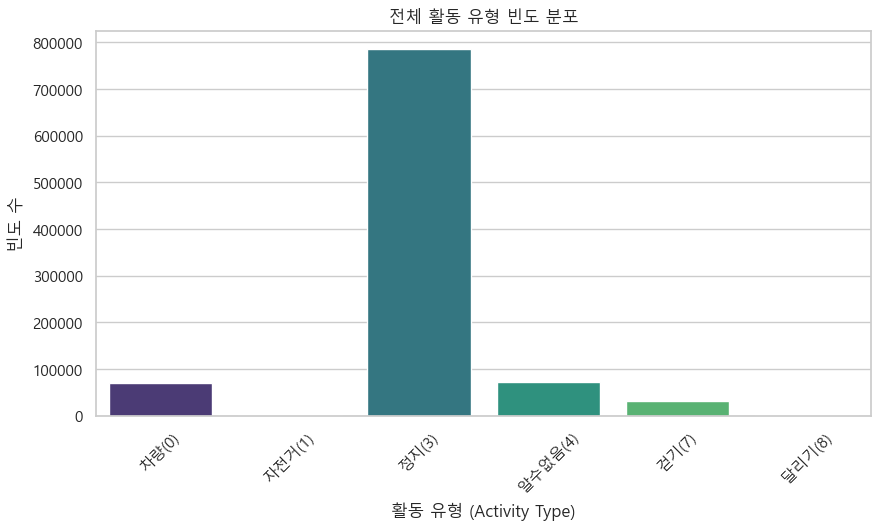

,activity_code,count,ratio,activity_name
2,0,70506,0.073363,차량(0)
4,1,1056,0.001099,자전거(1)
0,3,785792,0.817629,정지(3)
1,4,71502,0.074399,알수없음(4)
3,7,31404,0.032676,걷기(7)
5,8,802,0.000834,달리기(8)


In [3]:
activity_counts = df["m_activity"].value_counts().reset_index()
activity_counts.columns = ["activity_code", "count"]
activity_counts = activity_counts.sort_values(by="activity_code")
activity_counts["ratio"] = activity_counts["count"] / activity_counts["count"].sum()
activity_counts["activity_name"] = activity_counts["activity_code"].apply(ActivityType.to_name)

plt.figure(figsize=(10, 5))
sns.barplot(data=activity_counts, x="activity_name", y="count", hue="activity_name", palette="viridis", legend=False)
plt.title("전체 활동 유형 빈도 분포")
plt.xlabel("활동 유형 (Activity Type)")
plt.ylabel("빈도 수")
plt.xticks(rotation=45)
plt.show()
activity_counts

## 3. 참여자별 활동 분포 비교
각 참여자마다 어떤 신체 활동 코드 비중이 높은지 파악합니다.

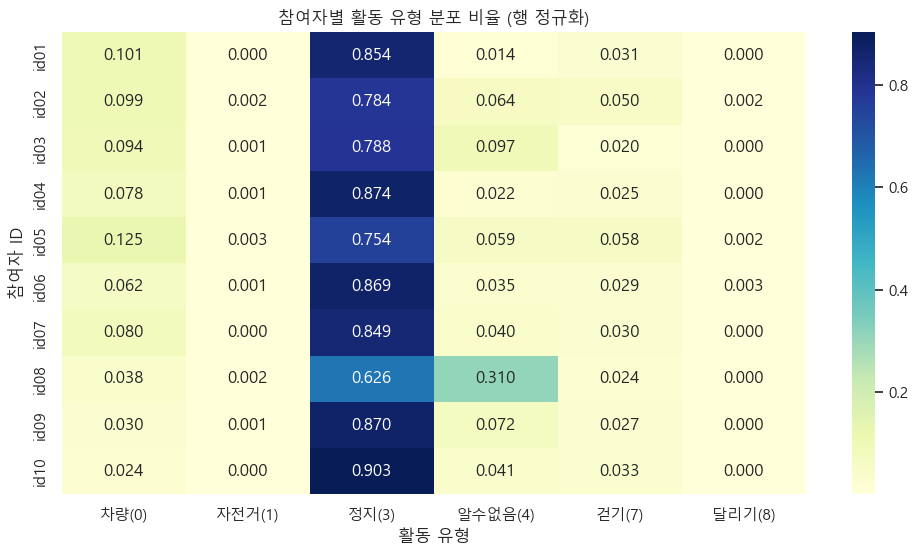

In [4]:
activity_pivot = pd.crosstab(df["subject_id"], df["m_activity"], normalize="index")
activity_pivot.columns = [ActivityType.to_name(col) for col in activity_pivot.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(activity_pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("참여자별 활동 유형 분포 비율 (행 정규화)")
plt.xlabel("활동 유형")
plt.ylabel("참여자 ID")
plt.show()

## 4. 시간대별 활동 비율 변화
시간에 따른 사용자의 활동 패턴을 파악하여 특정 시간에 활동량이 급증하는지 탐색합니다.

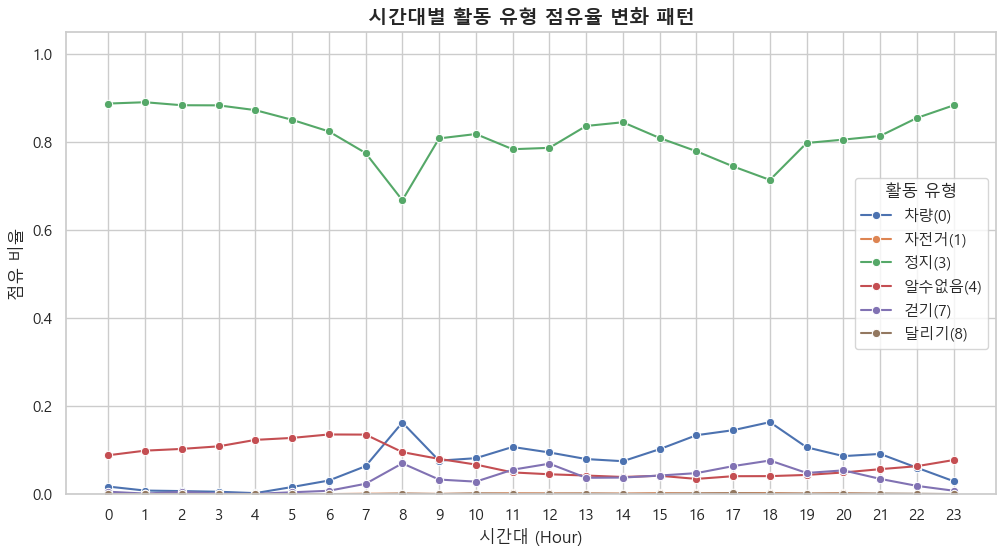

In [5]:
df["hour"] = df["timestamp"].dt.hour
# 시간대별 각 활동 유형의 점유 비율 계산
activity_hourly = df.groupby(["hour", "m_activity"]).size().unstack(fill_value=0)
activity_hourly_ratio = activity_hourly.div(activity_hourly.sum(axis=1), axis=0)
activity_hourly_ratio.columns = [ActivityType.to_name(col) for col in activity_hourly_ratio.columns]

plt.figure(figsize=(12, 6))
for col in activity_hourly_ratio.columns:
    sns.lineplot(data=activity_hourly_ratio, x=activity_hourly_ratio.index, y=col, marker="o", label=col)

plt.title("시간대별 활동 유형 점유율 변화 패턴", fontsize=14, fontweight="bold")
plt.xlabel("시간대 (Hour)")
plt.ylabel("점유 비율")
plt.xticks(range(0, 24))
plt.ylim(0, 1.05)
plt.legend(title="활동 유형")
plt.show()

## 5. 피처 엔지니어링 제안
* **`act_entropy`**: 일일 활동 코드의 엔트로피 (활동의 다양성).
* **`act_transitions`**: 활동 상태가 변한 횟수 (활동 전환율).
* **`act_ratio_{code}`**: 각 활동 코드가 하루 중 차지하는 비율.